<a href="https://colab.research.google.com/github/Arfa-Tariq/learning-ai-engineering/blob/main/projects/07-LangChain/04_Question_and_Answer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LangChain: Q&A over Documents

An example might be a tool that would allow you to query a product catalog for items of interest.

In [1]:
!pip install -q groq langchain-groq langchain-core langchain-classic langchain-community langchain sentence-transformers docarray

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 76.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.8/302.8 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [2]:
from langchain_groq import ChatGroq
from google.colab import userdata

GROQ_API_KEY = userdata.get('groq_key')
llm = ChatGroq(
    groq_api_key= GROQ_API_KEY,
    model="llama-3.3-70b-versatile",
    temperature= 0.9,
)

In [3]:
from langchain_classic.chains import RetrievalQA
from langchain_community.document_loaders import CSVLoader
from langchain_classic.vectorstores import DocArrayInMemorySearch
from IPython.display import display, Markdown

/tmp/ipykernel_834/673994173.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import CSVLoader


In [4]:
loader = CSVLoader(file_path='/content/OutdoorClothingCatalog_1000.csv')

**VectorstoreIndexCreator** is a utility class in the LangChain framework. It provides a convenient, one-line method to automatically load, split, embed, and store documents in a vector database for Retrieval-Augmented Generation (RAG) applications

Instead of manually configuring a document loader, a text splitter, an embedding model, and a vector store separately, VectorstoreIndexCreator streamlines the process into a single command.

Under the hood, it automatically executes these four steps:

1.   Load: Takes a list of document loaders (e.g., text files, PDFs, websites) and ingests the raw data.
2.   Split: Divides the loaded documents into smaller, manageable chunks so they fit within LLM context limits.
3.    Embed: Converts the text chunks into numerical vectors (embeddings) that represent their semantic meaning.
4.  Store & Index: Saves these vectors into a vector store (like Chroma or FAISS) so they can be searched efficiently


In [5]:
from langchain_classic.indexes import VectorstoreIndexCreator

In [6]:
import os
os.environ["HF_HUB_DISABLE_XET"] = "1"


In [7]:
!pip install -U huggingface_hub


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 771.9/771.9 kB 25.4 MB/s eta 0:00:00
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.23.0
    Uninstalling huggingface_hub-1.23.0:
      Successfully uninstalled huggingface_hub-1.23.0


In [8]:
from langchain_community.embeddings import HuggingFaceEmbeddings

# Initialize HuggingFaceEmbeddings with a common model
embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

index = VectorstoreIndexCreator(
    vectorstore_cls=DocArrayInMemorySearch,
    embedding=embeddings # Pass the initialized embedding model here
).from_loaders([loader])

/tmp/ipykernel_834/3807875073.py:4: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [9]:
query ="Please list all your shirts with sun protection \
in a table in markdown and summarize each one."

In [10]:
response = index.query(
    query,
    llm=llm
)

display(Markdown(response))

### Shirts with Sun Protection
| Shirt Name | Description | Fabric | UPF Rating | Care |
| --- | --- | --- | --- | --- |
| Women's Tropical Tee, Sleeveless | Sleeveless button-up shirt with SunSmart protection, wrinkle resistant, and low-profile pockets | 71% nylon, 29% polyester | 50+ | Machine wash and dry |
| Sun Shield Shirt | High-performance sun shirt with moisture-wicking fabric, abrasion resistant, and SPF 50+ sun protection | 78% nylon, 22% Lycra Xtra Life fiber | 50+ | Handwash, line dry |
| Tropical Breeze Shirt | Lightweight, breathable long-sleeve men's UPF shirt with SunSmart protection, wrinkle-resistant, and moisture-wicking fabric | 71% nylon, 29% polyester | 50+ | Machine wash and dry |
| Men's Plaid Tropic Shirt, Short-Sleeve | Ultracomfortable sun protection shirt with UPF 50+ rating, wrinkle-free, and quick-drying fabric | 52% polyester, 48% nylon | 50+ | Machine wash and dry |

Each of these shirts offers high-level sun protection with a UPF 50+ rating, blocking 98% of the sun's harmful UV rays. They also feature various comfortable and practical designs, such as wrinkle resistance, moisture-wicking fabric, and breathable construction.

![image.png](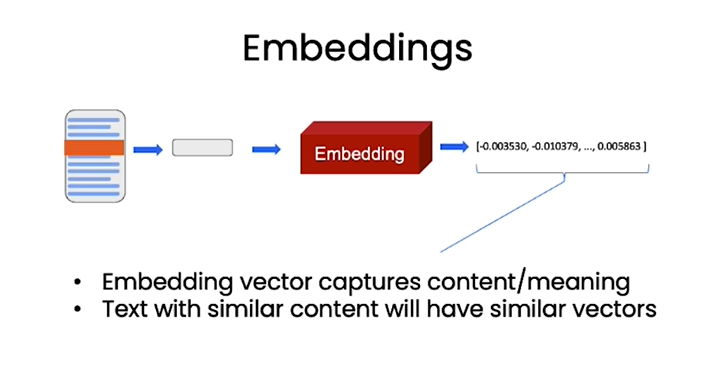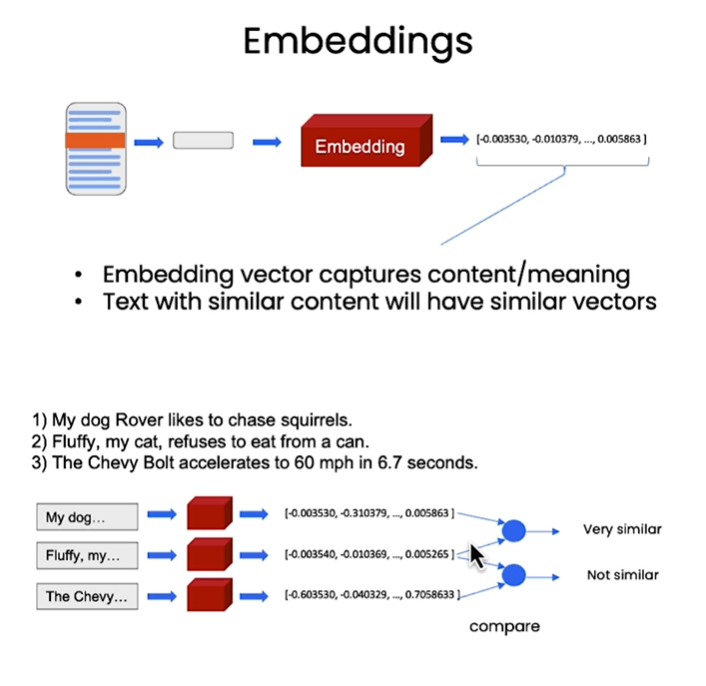)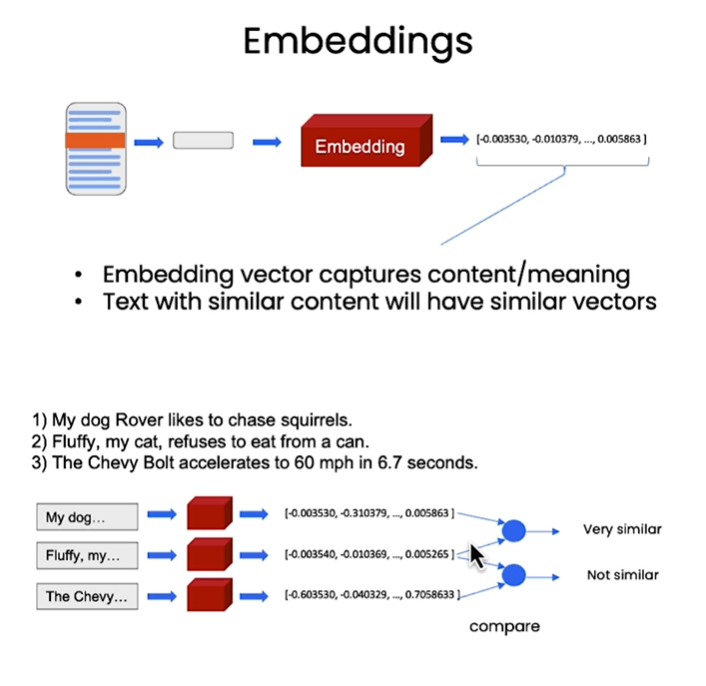

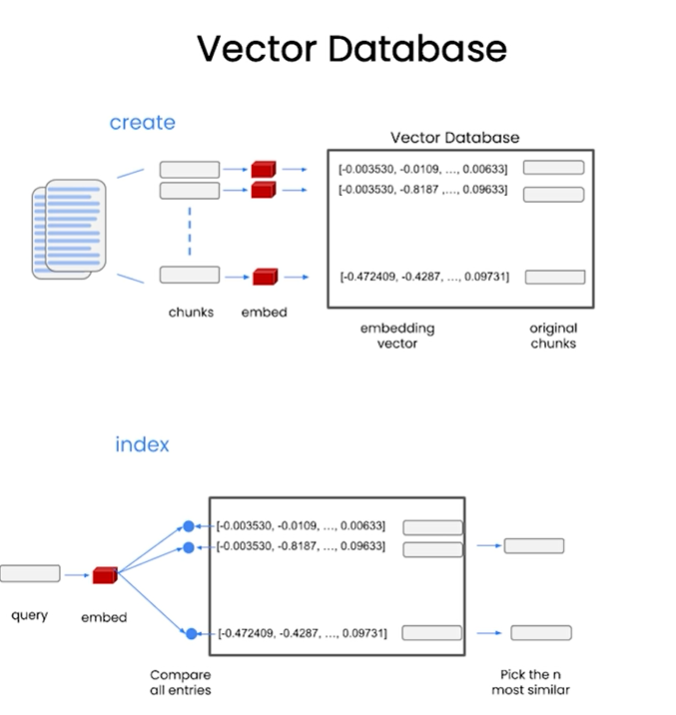

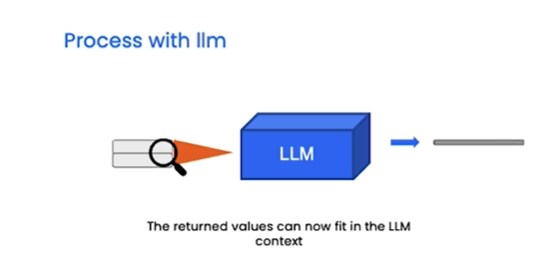

In [29]:
loader = CSVLoader(file_path='/content/OutdoorClothingCatalog_1000.csv')

In [30]:
docs = loader.load()

In [31]:
docs[0]

Document(metadata={'source': '/content/OutdoorClothingCatalog_1000.csv', 'row': 0}, page_content=": 0\nname: Women's Campside Oxfords\ndescription: This ultracomfortable lace-to-toe Oxford boasts a super-soft canvas, thick cushioning, and quality construction for a broken-in feel from the first time you put them on. \n\nSize & Fit: Order regular shoe size. For half sizes not offered, order up to next whole size. \n\nSpecs: Approx. weight: 1 lb.1 oz. per pair. \n\nConstruction: Soft canvas material for a broken-in feel and look. Comfortable EVA innersole with Cleansport NXT® antimicrobial odor control. Vintage hunt, fish and camping motif on innersole. Moderate arch contour of innersole. EVA foam midsole for cushioning and support. Chain-tread-inspired molded rubber outsole with modified chain-tread pattern. Imported. \n\nQuestions? Please contact us for any inquiries.")

In [32]:
embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [33]:
embed = embeddings.embed_query("Hi my name is Andrew")

In [34]:
print(len(embed))

384


In [35]:
print(embed[:5])

[-0.027908161282539368, -0.058227818459272385, 0.01393621414899826, -0.030836407095193863, -0.03675266355276108]


In [36]:
db  = DocArrayInMemorySearch.from_documents(
    docs,  #list of documents
    embeddings #embeddings object
    )

In [59]:
query = "Please suggest a shirt with sunblocking"

In [60]:
docs = db.similarity_search(query)

In [61]:
docs

[Document(metadata={'source': '/content/OutdoorClothingCatalog_1000.csv', 'row': 255}, page_content=': 255\nname: Sun Shield Shirt by\ndescription: "Block the sun, not the fun – our high-performance sun shirt is guaranteed to protect from harmful UV rays. \n\nSize & Fit: Slightly Fitted: Softly shapes the body. Falls at hip.\n\nFabric & Care: 78% nylon, 22% Lycra Xtra Life fiber. UPF 50+ rated – the highest rated sun protection possible. Handwash, line dry.\n\nAdditional Features: Wicks moisture for quick-drying comfort. Fits comfortably over your favorite swimsuit. Abrasion resistant for season after season of wear. Imported.\n\nSun Protection That Won\'t Wear Off\nOur high-performance fabric provides SPF 50+ sun protection, blocking 98% of the sun\'s harmful rays. This fabric is recommended by The Skin Cancer Foundation as an effective UV protectant.'),
 Document(metadata={'source': '/content/OutdoorClothingCatalog_1000.csv', 'row': 619}, page_content=": 619\nname: Tropical Breeze Sh

In [62]:
len(docs)

4

In [63]:
docs[0]

Document(metadata={'source': '/content/OutdoorClothingCatalog_1000.csv', 'row': 255}, page_content=': 255\nname: Sun Shield Shirt by\ndescription: "Block the sun, not the fun – our high-performance sun shirt is guaranteed to protect from harmful UV rays. \n\nSize & Fit: Slightly Fitted: Softly shapes the body. Falls at hip.\n\nFabric & Care: 78% nylon, 22% Lycra Xtra Life fiber. UPF 50+ rated – the highest rated sun protection possible. Handwash, line dry.\n\nAdditional Features: Wicks moisture for quick-drying comfort. Fits comfortably over your favorite swimsuit. Abrasion resistant for season after season of wear. Imported.\n\nSun Protection That Won\'t Wear Off\nOur high-performance fabric provides SPF 50+ sun protection, blocking 98% of the sun\'s harmful rays. This fabric is recommended by The Skin Cancer Foundation as an effective UV protectant.')

In [64]:
retriever  = db.as_retriever()

In [65]:
qdocs = "".join([docs[i].page_content for i in range(len(docs))])

In [66]:
response = llm.invoke(f"{qdocs} Question: Please list all your shirts with sun protection feature in a table in markdown and summarize each one.")

In [67]:
display(Markdown(response.content))

### Shirts with Sun Protection Feature
| Shirt Name | Description | Fabric | UPF Rating | Key Features |
| --- | --- | --- | --- | --- |
| Sun Shield Shirt | High-performance sun shirt for protection from harmful UV rays | 78% nylon, 22% Lycra Xtra Life fiber | UPF 50+ | Moisture-wicking, abrasion resistant, fits over swimsuit |
| Tropical Breeze Shirt | Lightweight, breathable long-sleeve men’s UPF shirt | 71% nylon, 29% polyester | UPF 50+ | Wrinkle-resistant, moisture-wicking, SunSmart technology |
| Men's Plaid Tropic Shirt | Ultracomfortable sun protection shirt | 52% polyester, 48% nylon | UPF 50+ | SunSmart technology, wrinkle-free, front and back cape venting |
| Women's Tropical Tee | Sleeveless button-up shirt with SunSmart protection | 71% nylon, 29% polyester | UPF 50+ | Wrinkle resistant, low-profile pockets, front and back cape venting |

### Summary
All four shirts have a sun protection feature with a UPF 50+ rating, which blocks 98% of the sun's harmful UV rays. The shirts are made from a combination of nylon and polyester fabrics, with some featuring moisture-wicking and wrinkle-resistant properties. The Sun Shield Shirt and Men's Plaid Tropic Shirt are designed for high-performance activities, while the Tropical Breeze Shirt and Women's Tropical Tee are more focused on comfort and style. Each shirt has unique features such as cape venting, pockets, and tool tabs, making them suitable for various outdoor activities and preferences.

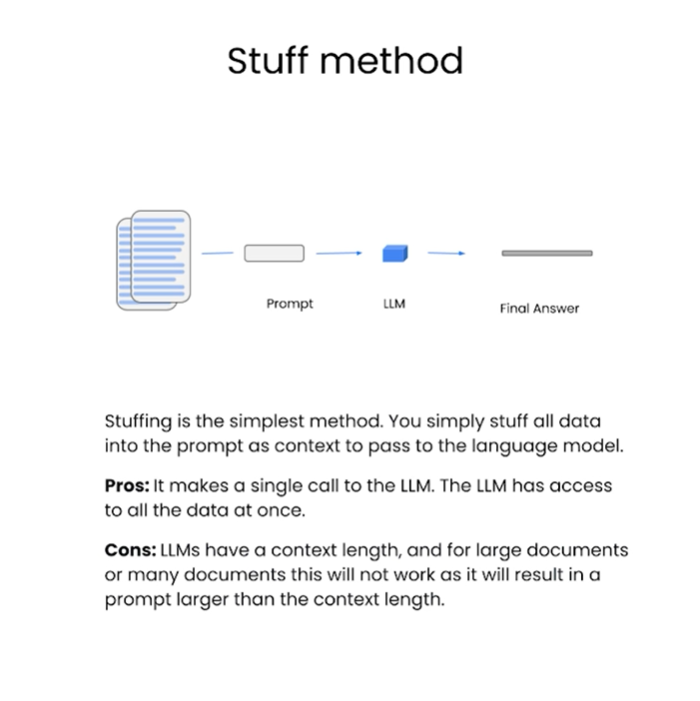

In [68]:
qa_stuff = RetrievalQA.from_chain_type(
    llm=llm,
    chain_type="stuff",
    retriever=retriever,
    verbose=True
)

In [69]:
query =  "Please list all your shirts with sun protection in a table \
in markdown and summarize each one."

In [70]:
response = qa_stuff.run(query)

/tmp/ipykernel_834/3485144879.py:1: LangChainDeprecationWarning: The method `Chain.run` was deprecated in langchain-classic 0.1.0 and will be removed in 2.0.0. Use `invoke` instead.
  response = qa_stuff.run(query)




> Entering new RetrievalQA chain...

> Finished chain.


In [71]:
display(Markdown(response))

### Shirts with Sun Protection
Here's a list of shirts with sun protection in a markdown table:

| Shirt Name | Description | UPF Rating | Fabric |
| --- | --- | --- | --- |
| Women's Tropical Tee | Sleeveless button-up shirt for women with SunSmart UPF 50+ protection, wrinkle-resistant, and breathable | 50+ | 71% nylon, 29% polyester |
| Sun Shield Shirt | High-performance sun shirt with UPF 50+ protection, moisture-wicking, and abrasion-resistant | 50+ | 78% nylon, 22% Lycra Xtra Life fiber |
| Sunrise Tee | Women's UV-protective button-down shirt with UPF 50+ protection, lightweight, and wrinkle-free | 50+ | 71% nylon, 29% polyester |
| Tropical Breeze Shirt | Men's long-sleeve UPF shirt with SunSmart protection, wrinkle-resistant, and moisture-wicking | 50+ | 71% nylon, 29% polyester |

Each of these shirts offers UPF 50+ sun protection, which blocks 98% of the sun's harmful UV rays. They are designed for outdoor activities and feature breathable, moisture-wicking fabrics to keep you cool and comfortable.

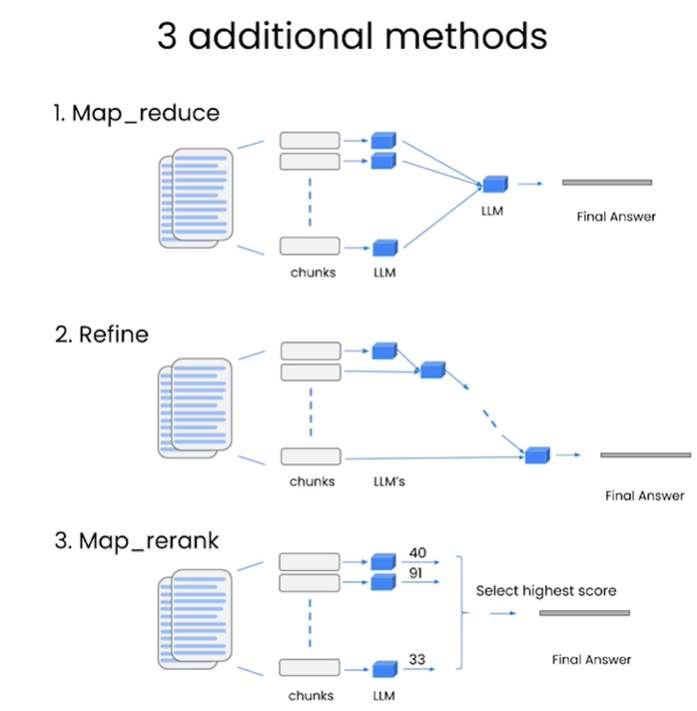

In [72]:
response = index.query(query, llm=llm)